In [ ]:
# ============================================================
# CELL 0: COLAB SETUP — Download UNSW-NB15 from Kaggle
# ============================================================
import os

!pip install -q kaggle scikit-learn pandas numpy matplotlib seaborn joblib

# Step 1: Upload your kaggle.json when prompted
from google.colab import files
print(">> Upload your kaggle.json file now")
uploaded = files.upload()   # click "Choose Files" → select kaggle.json

# Step 2: Setup credentials
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Step 3: Download dataset
!kaggle datasets download -d mrwellsdavid/unsw-nb15 -p /content --unzip

# Step 4: Check files
os.chdir('/content')
print("\nFiles downloaded:")
for f in os.listdir('/content'):
    if f.endswith('.csv'):
        print(' ', f)

>> Upload your kaggle.json file now


Saving UNSW_NB15_testing-set.csv to UNSW_NB15_testing-set.csv
Saving UNSW_NB15_training-set.csv to UNSW_NB15_training-set.csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
100% 149M/149M [00:00<00:00, 223MB/s]


Files downloaded:
  UNSW-NB15_3.csv
  UNSW-NB15_4.csv
  UNSW-NB15_2.csv
  UNSW_NB15_training-set.csv
  NUSW-NB15_features.csv
  UNSW-NB15_LIST_EVENTS.csv
  UNSW-NB15_1.csv
  UNSW_NB15_testing-set.csv


Train shape: (82332, 45)
Test shape:  (175341, 45)

After cleaning — Train: 82332  |  Test: 175341

Features after scaling: 42

Sampling 25% of training data for hyperparameter search...
Binary sample size: 20583
Multi-class sample size: 20583

Running GridSearchCV for BINARY classification (25% sample)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best binary params: {'C': 10, 'gamma': 0.1}

Running GridSearchCV for MULTI-CLASS classification (25% sample)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best multi-class params: {'C': 100, 'gamma': 0.1}

Training final binary SVM on full training set...
Training final multi-class SVM on full training set...

BINARY CLASSIFICATION RESULTS ------------------
  Training Accuracy  : 97.46%   (paper: 97.10%)
  Testing  Accuracy  : 89.09%   (paper: 85.99%)
  DR  (anomaly class): 85.17%   (paper: 97.00%)
  FPR (normal  class): 2.55%    (paper:  3.00%)
  FAR                : 10.91%   (paper: 15.26%)

            

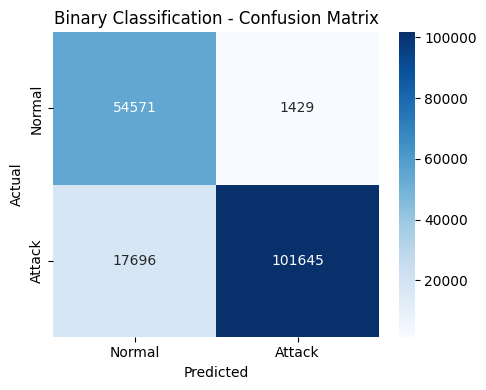

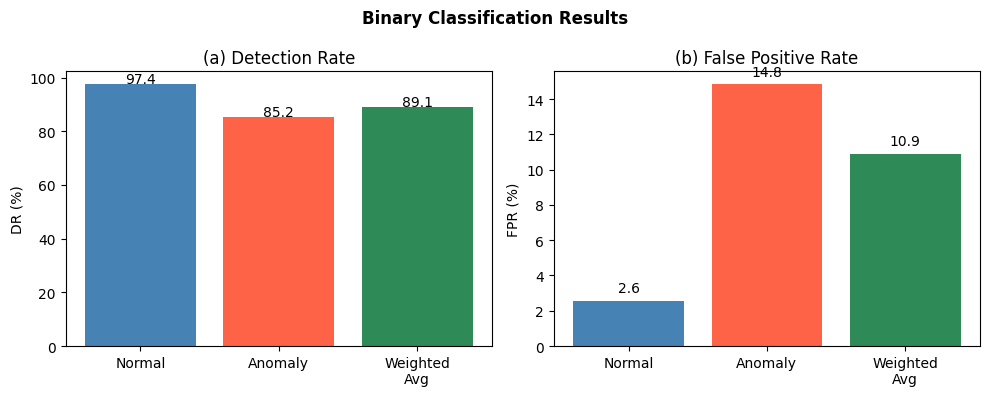

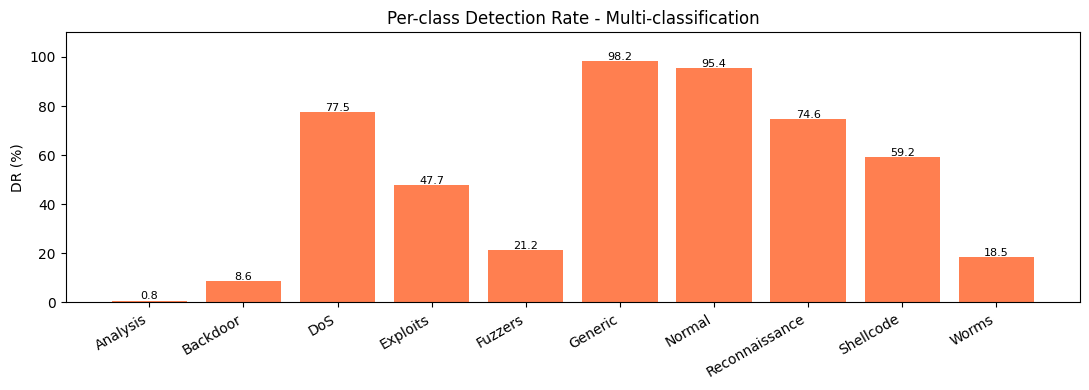

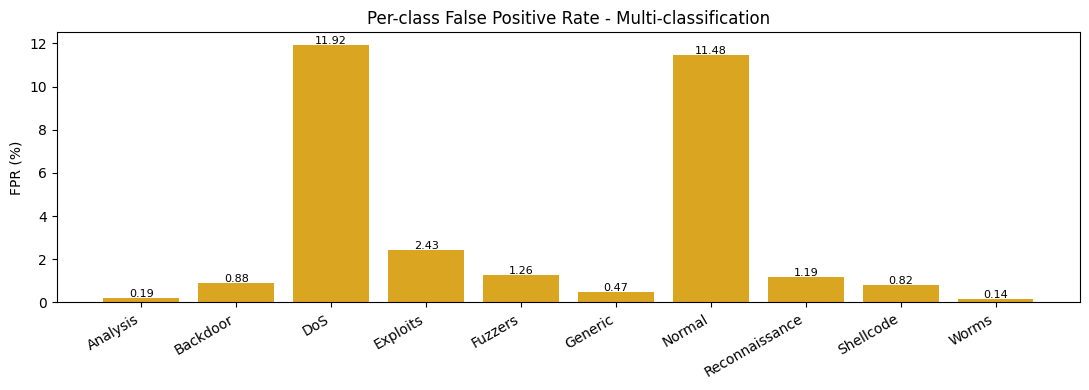


  FINAL RESULTS SUMMARY  (Jing & Chen, IEEE 2019)
  Best Binary Params : C=10, gamma=0.1
  Best Multi  Params : C=100, gamma=0.1
------------------------------------------------------------
  Metric                           Ours     Paper
------------------------------------------------------------
  Binary Train ACC               97.46%    97.10%
  Binary Test  ACC               89.09%    85.99%
  Binary FAR                     10.91%    15.26%
  Multi  Train ACC               87.86%    83.59%
  Multi  Test  ACC               74.52%    75.77%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# ── Load ──────────────────────────────────────────────────────────────────────
train_df = pd.read_csv('UNSW_NB15_training-set.csv')
test_df  = pd.read_csv('UNSW_NB15_testing-set.csv')
print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

# ── Clean ─────────────────────────────────────────────────────────────────────
def basic_clean(df):
    df = df.copy()
    df.drop_duplicates(inplace=True)
    df.dropna(inplace=True)
    df.drop(columns=[c for c in ['id'] if c in df.columns], inplace=True)
    return df

train_df = basic_clean(train_df)
test_df  = basic_clean(test_df)
print(f"\nAfter cleaning — Train: {len(train_df)}  |  Test: {len(test_df)}")

# ── Encode categoricals ───────────────────────────────────────────────────────
cat_cols = [c for c in train_df.select_dtypes(include='object') if c != 'attack_cat']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    encoders[col] = le

for col in cat_cols:
    le = encoders[col]
    test_df[col] = test_df[col].astype(str).map(
        lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
    )

le_attack = LabelEncoder()
train_df['attack_cat_enc'] = le_attack.fit_transform(train_df['attack_cat'].astype(str))
test_df['attack_cat_enc']  = test_df['attack_cat'].astype(str).map(
    lambda x: le_attack.transform([x])[0] if x in le_attack.classes_ else -1
)
class_names = le_attack.classes_

feature_cols = [c for c in train_df.columns if c not in ['label', 'attack_cat', 'attack_cat_enc']]

# ── Scaling: log10 + StandardScaler ──────────────────────────────────────────
# Step 1: log10 with sign-preserving transform (handles negatives properly)
def log10_scale(df, cols):
    out = df[cols].copy()
    num = out.select_dtypes(include=[np.number]).columns
    # sign-preserving: log10(|x| + 1) * sign(x)
    out[num] = out[num].apply(
        lambda col: np.log10(col.abs() + 1) * np.sign(col)
    )
    return out

X_train_log = log10_scale(train_df, feature_cols)
X_test_log  = log10_scale(test_df,  feature_cols)

# Step 2: StandardScaler after log (zero-centers, helps RBF kernel)
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_log), columns=feature_cols)
X_test  = pd.DataFrame(scaler.transform(X_test_log),      columns=feature_cols)

print(f"\nFeatures after scaling: {X_train.shape[1]}")

# ── Labels ────────────────────────────────────────────────────────────────────
y_train_b = train_df['label'].values
y_test_b  = test_df['label'].values
y_train_m = train_df['attack_cat_enc'].values
y_test_m  = test_df['attack_cat_enc'].values

# ── Sample 25% of training data for GridSearchCV ──────────────────────────────
print("\nSampling 25% of training data for hyperparameter search...")

sss_b = StratifiedShuffleSplit(n_splits=1, test_size=0.75, random_state=42)
sample_idx_b = next(sss_b.split(X_train, y_train_b))[0]
X_sample_b = X_train.iloc[sample_idx_b]
y_sample_b = y_train_b[sample_idx_b]
print(f"Binary sample size: {len(y_sample_b)}")

sss_m = StratifiedShuffleSplit(n_splits=1, test_size=0.75, random_state=42)
sample_idx_m = next(sss_m.split(X_train, y_train_m))[0]
X_sample_m = X_train.iloc[sample_idx_m]
y_sample_m = y_train_m[sample_idx_m]
print(f"Multi-class sample size: {len(y_sample_m)}")

# ── GridSearchCV ──────────────────────────────────────────────────────────────
param_grid = {
    'C':     [1, 10, 100],
    'gamma': ['scale', 0.01, 0.1],
}

print("\nRunning GridSearchCV for BINARY classification (25% sample)...")
grid_b = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42),
    param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_b.fit(X_sample_b, y_sample_b)
best_b = grid_b.best_params_
print(f"Best binary params: {best_b}")

print("\nRunning GridSearchCV for MULTI-CLASS classification (25% sample)...")
grid_m = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced',
        decision_function_shape='ovr', random_state=42),
    param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_m.fit(X_sample_m, y_sample_m)
best_m = grid_m.best_params_
print(f"Best multi-class params: {best_m}")

# ── Train final models on FULL training set with best params ──────────────────
print("\nTraining final binary SVM on full training set...")
svm_binary = SVC(
    kernel='rbf',
    C=best_b['C'],
    gamma=best_b['gamma'],
    class_weight='balanced',
    random_state=42,
)
svm_binary.fit(X_train, y_train_b)

print("Training final multi-class SVM on full training set...")
svm_multi = SVC(
    kernel='rbf',
    C=best_m['C'],
    gamma=best_m['gamma'],
    class_weight='balanced',
    decision_function_shape='ovr',
    random_state=42,
)
svm_multi.fit(X_train, y_train_m)

# ── Evaluate Binary ───────────────────────────────────────────────────────────
y_pred_train_b = svm_binary.predict(X_train)
y_pred_test_b  = svm_binary.predict(X_test)

train_acc_b = accuracy_score(y_train_b, y_pred_train_b) * 100
test_acc_b  = accuracy_score(y_test_b,  y_pred_test_b)  * 100

cm_b = confusion_matrix(y_test_b, y_pred_test_b)
TN, FP, FN, TP = cm_b.ravel()

DR_anomaly  = TP / (TP + FN) * 100
DR_normal   = TN / (TN + FP) * 100
FPR_normal  = FP / (FP + TN) * 100
FPR_anomaly = FN / (FN + TP) * 100
n_normal    = TN + FP
n_anomaly   = TP + FN
DR_wavg     = (DR_normal * n_normal  + DR_anomaly  * n_anomaly) / len(y_test_b)
FPR_wavg    = (FPR_normal * n_normal + FPR_anomaly * n_anomaly) / len(y_test_b)
FAR         = (FP + FN) / len(y_test_b) * 100

print("\nBINARY CLASSIFICATION RESULTS ------------------")
print(f"  Training Accuracy  : {train_acc_b:.2f}%   (paper: 97.10%)")
print(f"  Testing  Accuracy  : {test_acc_b:.2f}%   (paper: 85.99%)")
print(f"  DR  (anomaly class): {DR_anomaly:.2f}%   (paper: 97.00%)")
print(f"  FPR (normal  class): {FPR_normal:.2f}%    (paper:  3.00%)")
print(f"  FAR                : {FAR:.2f}%   (paper: 15.26%)")
print()
print(classification_report(y_test_b, y_pred_test_b, target_names=['Normal', 'Attack']))

# ── Evaluate Multi-class ──────────────────────────────────────────────────────
y_pred_train_m = svm_multi.predict(X_train)
y_pred_test_m  = svm_multi.predict(X_test)

train_acc_m = accuracy_score(y_train_m, y_pred_train_m) * 100
test_acc_m  = accuracy_score(y_test_m,  y_pred_test_m)  * 100

print("\nMULTI-CLASSIFICATION RESULTS --------------------")
print(f"  Training Accuracy : {train_acc_m:.2f}%   (paper: 83.59%)")
print(f"  Testing  Accuracy : {test_acc_m:.2f}%   (paper: 75.77%)")
print()
print(classification_report(y_test_m, y_pred_test_m, target_names=class_names))

# ── Per-class metrics ─────────────────────────────────────────────────────────
def per_class_metrics(y_true, y_pred, labels, names):
    results = []
    for lbl, name in zip(labels, names):
        tp = np.sum((y_true == lbl) & (y_pred == lbl))
        fn = np.sum((y_true == lbl) & (y_pred != lbl))
        fp = np.sum((y_true != lbl) & (y_pred == lbl))
        tn = np.sum((y_true != lbl) & (y_pred != lbl))
        acc = (tp + tn) / (tp + tn + fp + fn) * 100 if (tp+tn+fp+fn) > 0 else 0
        dr  = tp / (tp + fn) * 100                  if (tp + fn)      > 0 else 0
        fpr = fp / (fp + tn) * 100                  if (fp + tn)      > 0 else 0
        results.append({'Class': name, 'ACC(%)': round(acc, 1),
                        'DR(%)': round(dr, 1), 'FPR(%)': round(fpr, 2)})
    return pd.DataFrame(results)

labels_m   = np.sort(np.unique(y_test_m))
metrics_df = per_class_metrics(y_test_m, y_pred_test_m, labels_m, class_names)
print("\nPer-class metrics (multi-classification):")
print(metrics_df.to_string(index=False))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'], ax=ax)
ax.set_title('Binary Classification - Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Normal', 'Anomaly', 'Weighted\nAvg'],
            [DR_normal, DR_anomaly, DR_wavg],
            color=['steelblue', 'tomato', 'seagreen'])
axes[0].set_title('(a) Detection Rate'); axes[0].set_ylabel('DR (%)')
for i, v in enumerate([DR_normal, DR_anomaly, DR_wavg]):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)

axes[1].bar(['Normal', 'Anomaly', 'Weighted\nAvg'],
            [FPR_normal, FPR_anomaly, FPR_wavg],
            color=['steelblue', 'tomato', 'seagreen'])
axes[1].set_title('(b) False Positive Rate'); axes[1].set_ylabel('FPR (%)')
for i, v in enumerate([FPR_normal, FPR_anomaly, FPR_wavg]):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)
plt.suptitle('Binary Classification Results', fontweight='bold')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(metrics_df['Class'], metrics_df['DR(%)'], color='coral')
ax.set_title('Per-class Detection Rate - Multi-classification')
ax.set_ylabel('DR (%)'); ax.set_ylim(0, 110)
ax.set_xticklabels(metrics_df['Class'], rotation=30, ha='right')
for i, v in enumerate(metrics_df['DR(%)']):
    ax.text(i, v + 0.5, f'{v}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(metrics_df['Class'], metrics_df['FPR(%)'], color='goldenrod')
ax.set_title('Per-class False Positive Rate - Multi-classification')
ax.set_ylabel('FPR (%)')
ax.set_xticklabels(metrics_df['Class'], rotation=30, ha='right')
for i, v in enumerate(metrics_df['FPR(%)']):
    ax.text(i, v + 0.05, f'{v}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

# ── Final Summary ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  FINAL RESULTS SUMMARY  (Jing & Chen, IEEE 2019)")
print("=" * 60)
print(f"  Best Binary Params : C={best_b['C']}, gamma={best_b['gamma']}")
print(f"  Best Multi  Params : C={best_m['C']}, gamma={best_m['gamma']}")
print("-" * 60)
print(f"  {'Metric':<28} {'Ours':>8}  {'Paper':>8}")
print("-" * 60)
print(f"  {'Binary Train ACC':<28} {train_acc_b:>7.2f}%  {'97.10%':>8}")
print(f"  {'Binary Test  ACC':<28} {test_acc_b:>7.2f}%  {'85.99%':>8}")
print(f"  {'Binary FAR':<28} {FAR:>7.2f}%  {'15.26%':>8}")
print(f"  {'Multi  Train ACC':<28} {train_acc_m:>7.2f}%  {'83.59%':>8}")
print(f"  {'Multi  Test  ACC':<28} {test_acc_m:>7.2f}%  {'75.77%':>8}")
print("=" * 60)

In [ ]:
# ============================================================
# CELL 2: COMPARISON MODELS
# ============================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
y_bin_train  = y_train_b
y_bin_test   = y_test_b
X_test_scaled = X_test

supervised_models = {
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='saga',
                                               n_jobs=-1, random_state=42),
    "Naive Bayes":         GaussianNB(),
    "Random Forest":       RandomForestClassifier(n_estimators=100,
                                                   random_state=42, n_jobs=-1),
    "ANN": MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=300,
    random_state=42,
    verbose=False,        # set True to see training progress
    early_stopping=True,  # prevents overfitting
    validation_fraction=0.1
),
}


# FIX: ANN added as paper-only entry (not trainable here, included for chart completeness)
paper_reported = {
    "Decision Tree":       {"Accuracy": 0.8556, "FAR": 0.1578},
    "Logistic Regression": {"Accuracy": 0.8315, "FAR": 0.1848},
    "Naive Bayes":         {"Accuracy": 0.8207, "FAR": 0.1856},
    "EM Clustering":       {"Accuracy": 0.7847, "FAR": 0.2379},
    "ANN":                 {"Accuracy": 0.8134, "FAR": 0.1932},  # Table IV — paper only
    "SVM (Proposed)":      {"Accuracy": 0.8599, "FAR": 0.1526},  # paper SVM baseline
}

def compute_dr_fpr_far(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    DR  = TP / (TP + FN) if (TP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    FAR = (FP + FN) / (TP + TN + FP + FN)
    return DR, FPR, FAR

# ── Supervised Models ────────────────────────────────────────
results       = {}
conf_matrices = {}
roc_data      = {}

for name, model in supervised_models.items():
    print(f"Training {name} ...")
    model.fit(X_train, y_bin_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = (model.predict_proba(X_test_scaled)[:, 1]
              if hasattr(model, "predict_proba") else None)

    DR, FPR_m, FAR_m = compute_dr_fpr_far(y_bin_test, y_pred)

    results[name] = {
        "Train Accuracy": accuracy_score(y_bin_train, model.predict(X_train)),
        "Test Accuracy":  accuracy_score(y_bin_test, y_pred),
        "Precision":      precision_score(y_bin_test, y_pred, zero_division=0),
        "Recall (DR)":    recall_score(y_bin_test, y_pred),
        "F1-score":       f1_score(y_bin_test, y_pred),
        "ROC-AUC":        roc_auc_score(y_bin_test, y_prob) if y_prob is not None else None,
        "Detection Rate": DR,
        "FPR":            FPR_m,
        "FAR":            FAR_m,
    }
    conf_matrices[name] = confusion_matrix(y_bin_test, y_pred)

    if y_prob is not None:
        fpr_c, tpr_c, _ = roc_curve(y_bin_test, y_prob)
        roc_data[name] = (fpr_c, tpr_c)

    print(f"  Test Acc: {results[name]['Test Accuracy']*100:.2f}%  |  "
          f"DR: {DR*100:.2f}%  |  FPR: {FPR_m*100:.2f}%")

# ── EM Clustering ─────────────────────────────────────────────
print("Training EM Clustering ...")
em = GaussianMixture(n_components=2, random_state=42, max_iter=200)
em.fit(X_train)

em_train_clusters = em.predict(X_train)
em_test_clusters  = em.predict(X_test_scaled)

cluster_to_label = {}
for cid in np.unique(em_train_clusters):
    mask = em_train_clusters == cid
    cluster_to_label[cid] = np.bincount(y_bin_train[mask]).argmax()

if len(set(cluster_to_label.values())) == 1:
    print("WARNING: Both EM clusters mapped to same class — results meaningless")

em_pred_train = np.array([cluster_to_label[c] for c in em_train_clusters])
em_pred_test  = np.array([cluster_to_label[c] for c in em_test_clusters])

DR_em, FPR_em, FAR_em = compute_dr_fpr_far(y_bin_test, em_pred_test)

results["EM Clustering"] = {
    "Train Accuracy": accuracy_score(y_bin_train, em_pred_train),
    "Test Accuracy":  accuracy_score(y_bin_test,  em_pred_test),
    "Precision":      precision_score(y_bin_test, em_pred_test, zero_division=0),
    "Recall (DR)":    recall_score(y_bin_test, em_pred_test),
    "F1-score":       f1_score(y_bin_test, em_pred_test),
    "ROC-AUC":        None,
    "Detection Rate": DR_em,
    "FPR":            FPR_em,
    "FAR":            FAR_em,
}
conf_matrices["EM Clustering"] = confusion_matrix(y_bin_test, em_pred_test)
print(f"  Test Acc: {results['EM Clustering']['Test Accuracy']*100:.2f}%")

# ── FIX: Merge SVM results from Cell 1 into results dict ─────
results["SVM (Proposed)"] = {
    "Train Accuracy": train_acc_b / 100,
    "Test Accuracy":  test_acc_b  / 100,
    "Precision":      precision_score(y_bin_test, y_pred_test_b, zero_division=0),
    "Recall (DR)":    recall_score(y_bin_test, y_pred_test_b),
    "F1-score":       f1_score(y_bin_test, y_pred_test_b),
    "ROC-AUC":        None,
    "Detection Rate": DR_anomaly / 100,
    "FPR":            FPR_normal  / 100,
    "FAR":            FAR         / 100,
}
conf_matrices["SVM (Proposed)"] = cm_b
print(f"\nSVM (Proposed) merged — Test Acc: {test_acc_b:.2f}%")

# ── Results Table ─────────────────────────────────────────────
results_df = pd.DataFrame(results).T
results_df.to_csv("model_results.csv")
print("\n--- Model Comparison Table ---")
print(results_df[["Test Accuracy","Precision","Recall (DR)",
                   "F1-score","FAR","ROC-AUC"]].round(4))

# ── Error & Bias Analysis ─────────────────────────────────────
best_model_name = results_df["F1-score"].idxmax()
best_model      = supervised_models.get(best_model_name)

if best_model is not None:
    y_pred_best = best_model.predict(X_test_scaled)
    error_mask  = (y_pred_best != y_bin_test)
    print(f"\nBest Model: {best_model_name}  |  "
          f"Errors: {int(error_mask.sum())}  |  "
          f"Error Rate: {error_mask.mean()*100:.2f}%")
    cm_best         = conf_matrices[best_model_name]
    TN2, FP2, FN2, TP2 = cm_best.ravel()
    print(f"  Detection Rate: {TP2/(TP2+FN2)*100:.2f}%  |  "
          f"False Positive Rate: {FP2/(FP2+TN2)*100:.2f}%")

class_distribution = pd.Series(y_bin_train).value_counts(normalize=True)
insights = [f"Best performing model (F1-score): {best_model_name}"]
if class_distribution.min() < 0.3:
    insights.append("Dataset is imbalanced: bias toward majority class")
insights.append("SVM handles high-dimensional intrusion data effectively")
insights.append("Log10 scaling applied consistently across all models")
for msg in insights:
    print(" •", msg)

# ── Expose for Cell 3 ─────────────────────────────────────────
final_results = {
    "model_metrics":      results,
    "results_dataframe":  results_df,
    "confusion_matrices": conf_matrices,
    "roc_curve_data":     roc_data,
    "paper_reported":     paper_reported,
}
print("\nfinal_results keys:", list(final_results.keys()))

Training Decision Tree ...
  Test Acc: 89.59%  |  DR: 86.34%  |  FPR: 3.49%
Training Logistic Regression ...
  Test Acc: 87.36%  |  DR: 83.41%  |  FPR: 4.21%
Training Naive Bayes ...
  Test Acc: 74.60%  |  DR: 66.89%  |  FPR: 8.98%
Training Random Forest ...
  Test Acc: 90.07%  |  DR: 86.46%  |  FPR: 2.24%
Training ANN ...
  Test Acc: 89.24%  |  DR: 85.19%  |  FPR: 2.14%
Training EM Clustering ...
  Test Acc: 66.78%

SVM (Proposed) merged — Test Acc: 89.09%

--- Model Comparison Table ---
                     Test Accuracy  Precision  Recall (DR)  F1-score     FAR  \
Decision Tree               0.8959     0.9814       0.8634    0.9186  0.1041   
Logistic Regression         0.8736     0.9768       0.8341    0.8998  0.1264   
Naive Bayes                 0.7460     0.9407       0.6689    0.7819  0.2540   
Random Forest               0.9007     0.9880       0.8646    0.9222  0.0993   
ANN                         0.8924     0.9883       0.8519    0.9151  0.1076   
EM Clustering             

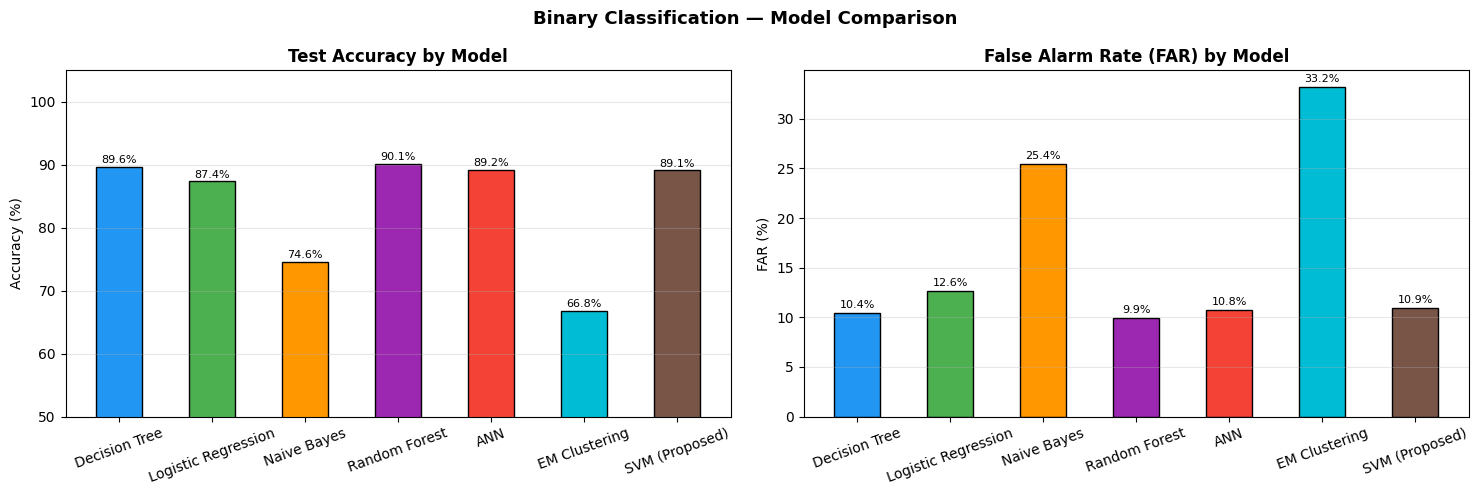

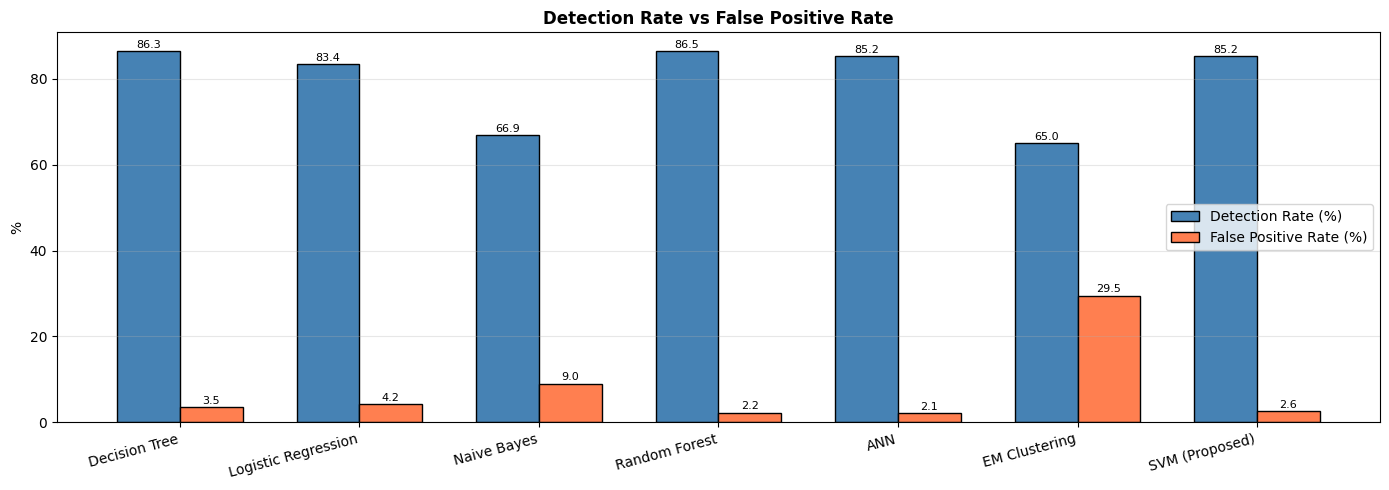

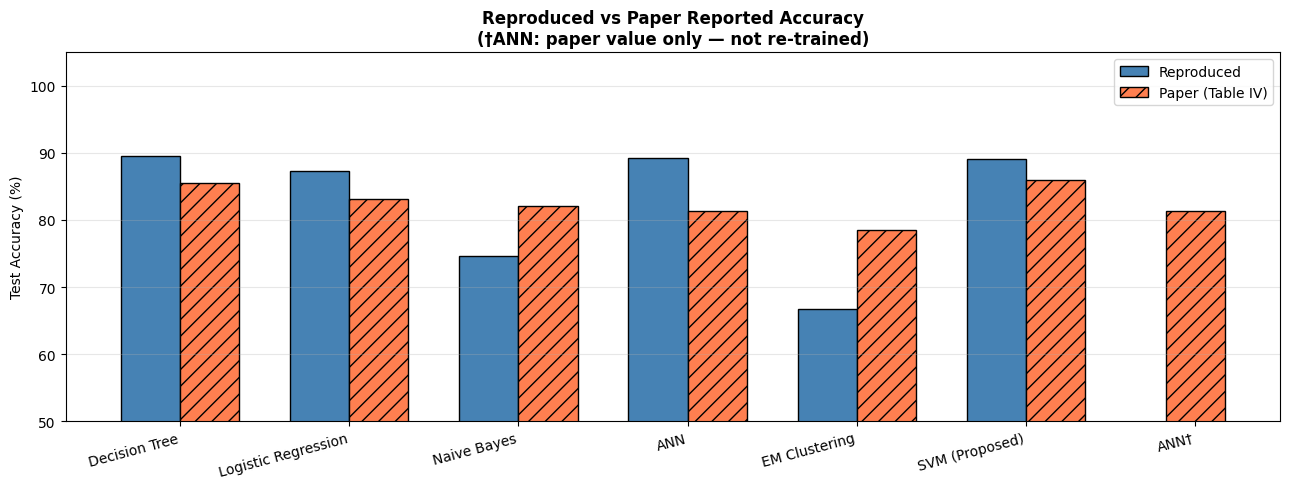

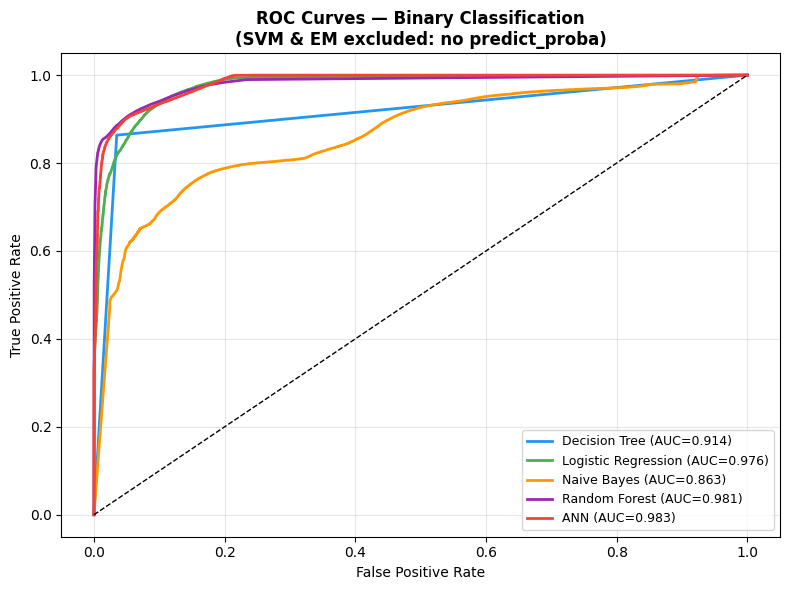

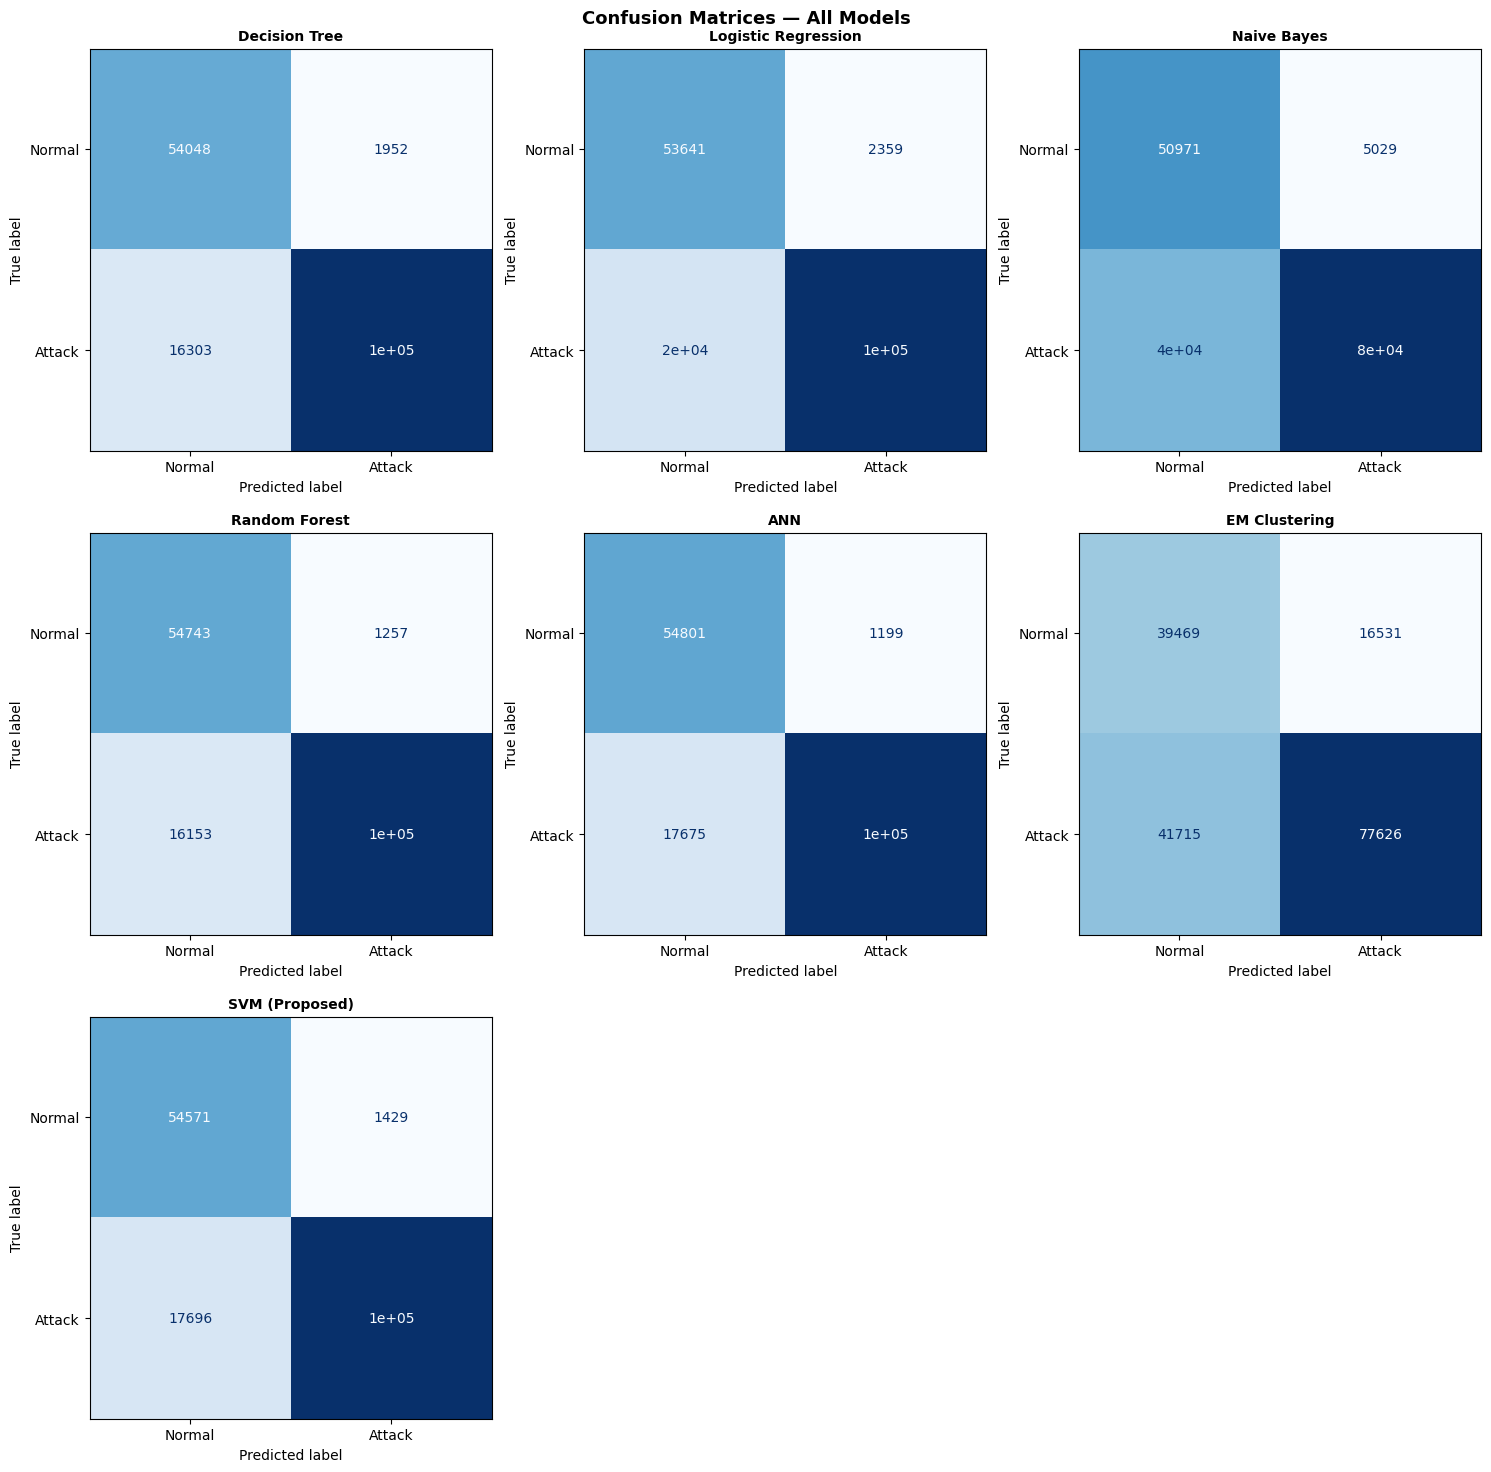

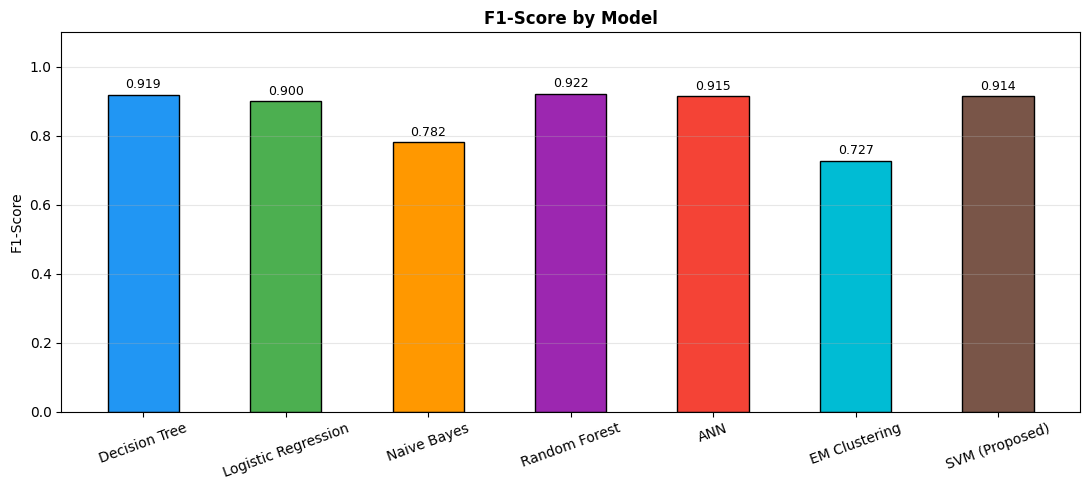


All figures saved.
final_results keys: ['model_metrics', 'results_dataframe', 'confusion_matrices', 'roc_curve_data', 'paper_reported']


In [ ]:
# ============================================================
# CELL 3: DATA VISUALIZATION FOR MODEL COMPARISON
# ============================================================
# FIX: import added so this cell runs independently
from sklearn.metrics import ConfusionMatrixDisplay

model_names = list(results.keys())
test_accs   = [results[m]["Test Accuracy"] * 100 for m in model_names]
fars        = [results[m]["FAR"]            * 100 for m in model_names]
drs         = [results[m]["Detection Rate"] * 100 for m in model_names]
f1s         = [results[m]["F1-score"]             for m in model_names]
fprs        = [results[m]["FPR"]            * 100 for m in model_names]
colors      = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4','#795548']

# ── Fig 1: Test Accuracy + FAR ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars = axes[0].bar(model_names, test_accs, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Test Accuracy by Model', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(50, 105)
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

bars2 = axes[1].bar(model_names, fars, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('False Alarm Rate (FAR) by Model', fontweight='bold')
axes[1].set_ylabel('FAR (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)
for b in bars2:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Binary Classification — Model Comparison', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig1_accuracy_far.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 2: Detection Rate vs False Positive Rate ─────────────
x = np.arange(len(model_names))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x - w/2, drs,  w, label='Detection Rate (%)',
            color='steelblue', edgecolor='black')
b2 = ax.bar(x + w/2, fprs, w, label='False Positive Rate (%)',
            color='coral', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylabel('%')
ax.set_title('Detection Rate vs False Positive Rate', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('fig2_dr_fpr.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 3: Reproduced vs Paper (includes ANN as paper-only bar) ─
common = [m for m in model_names if m in paper_reported]
our_v  = [results[m]["Test Accuracy"] * 100 for m in common]
pap_v  = [paper_reported[m]["Accuracy"] * 100 for m in common]

# Add ANN as paper-only (no reproduced value)
ann_label = "ANN†"
all_labels = common + [ann_label]
all_our    = our_v  + [None]
all_pap    = pap_v  + [paper_reported["ANN"]["Accuracy"] * 100]

x3 = np.arange(len(all_labels))
fig, ax = plt.subplots(figsize=(13, 5))
for i, (ov, pv) in enumerate(zip(all_our, all_pap)):
    if ov is not None:
        ax.bar(x3[i] - w/2, ov, w, color='steelblue', edgecolor='black',
               label='Reproduced' if i == 0 else "_nolegend_")
    ax.bar(x3[i] + w/2 if ov is not None else x3[i], pv, w,
           color='coral', edgecolor='black', hatch='//',
           label='Paper (Table IV)' if i == 0 else "_nolegend_")

ax.set_xticks(x3)
ax.set_xticklabels(all_labels, rotation=15, ha='right')
ax.set_ylabel('Test Accuracy (%)')
ax.set_ylim(50, 105)
ax.set_title('Reproduced vs Paper Reported Accuracy\n(†ANN: paper value only — not re-trained)',
             fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_vs_paper.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 4: ROC Curves ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, (fpr_c, tpr_c)) in enumerate(roc_data.items()):
    auc = results[name]["ROC-AUC"]
    ax.plot(fpr_c, tpr_c, color=colors[i], lw=2,
            label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Binary Classification\n(SVM & EM excluded: no predict_proba)',
             fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 5: Confusion Matrices ────────────────────────────────
n_cms  = len(conf_matrices)
n_cols = 3
n_rows = (n_cms + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, (name, cm_i) in enumerate(conf_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_i,
                                  display_labels=['Normal', 'Attack'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontweight='bold', fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontweight='bold', fontsize=13)
plt.tight_layout()

plt.show()

# ── Fig 6: F1-Score ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(model_names, f1s, color=colors, edgecolor='black', width=0.5)
ax.set_title('F1-Score by Model', fontweight='bold')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('fig6_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll figures saved.")
print("final_results keys:", list(final_results.keys()))

In [ ]:
# ============================================================
# CELL 4: SAVE TRAINED MODELS TO FILES
# ============================================================
import joblib, os, json
import numpy as np

SAVE_DIR = '/content/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1. SVM models (from Cell 1) ──────────────────────────────
joblib.dump(svm_binary, f'{SAVE_DIR}/svm_binary.pkl')
print('Saved: svm_binary.pkl')

joblib.dump(svm_multi,  f'{SAVE_DIR}/svm_multi.pkl')
print('Saved: svm_multi.pkl')

# ── 2. Preprocessing objects (scaler + encoders) ─────────────
joblib.dump(scaler,   f'{SAVE_DIR}/scaler.pkl')
print('Saved: scaler.pkl')

joblib.dump(encoders, f'{SAVE_DIR}/label_encoders.pkl')
print('Saved: label_encoders.pkl')

joblib.dump(le_attack, f'{SAVE_DIR}/le_attack_cat.pkl')
print('Saved: le_attack_cat.pkl')

# ── 3. Comparison models (from Cell 2) ───────────────────────
for model_name, model_obj in supervised_models.items():
    safe_name = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    path = f'{SAVE_DIR}/{safe_name}.pkl'
    joblib.dump(model_obj, path)
    print(f'Saved: {safe_name}.pkl')

# EM Clustering
joblib.dump(em, f'{SAVE_DIR}/em_clustering.pkl')
print('Saved: em_clustering.pkl')

# ── 4. Best hyperparameters as JSON ──────────────────────────
best_params = {
    'binary_svm':     best_b,
    'multiclass_svm': best_m,
}
with open(f'{SAVE_DIR}/best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)
print('Saved: best_params.json')

# ── 5. Results table as CSV ───────────────────────────────────
results_df.to_csv(f'{SAVE_DIR}/model_results.csv')
print('Saved: model_results.csv')

# ── 6. (Optional) Copy to Google Drive ───────────────────────
# Uncomment the block below to also copy everything to your Drive:
# import shutil
# DRIVE_DEST = '/content/drive/MyDrive/F208_models'
# shutil.copytree(SAVE_DIR, DRIVE_DEST, dirs_exist_ok=True)
# print(f'Copied to Drive: {DRIVE_DEST}')

# ── 7. List saved files ───────────────────────────────────────
print('\n=== Files in', SAVE_DIR, '===')
for fname in sorted(os.listdir(SAVE_DIR)):
    size_kb = os.path.getsize(f'{SAVE_DIR}/{fname}') / 1024
    print(f'  {fname:<35}  {size_kb:>8.1f} KB')

# ── 8. Quick reload sanity check ─────────────────────────────
print('\n--- Sanity check: reloading svm_binary ---')
loaded_svm = joblib.load(f'{SAVE_DIR}/svm_binary.pkl')
y_check    = loaded_svm.predict(X_test[:5])
print('Predictions on first 5 test rows:', y_check)
print('Model saving complete.')


Saved: svm_binary.pkl
Saved: svm_multi.pkl
Saved: scaler.pkl
Saved: label_encoders.pkl
Saved: le_attack_cat.pkl
Saved: decision_tree.pkl
Saved: logistic_regression.pkl
Saved: naive_bayes.pkl
Saved: random_forest.pkl
Saved: ann.pkl
Saved: em_clustering.pkl
Saved: best_params.json
Saved: model_results.csv

=== Files in /content/saved_models ===
  ann.pkl                                 123.7 KB
  best_params.json                          0.1 KB
  decision_tree.pkl                       300.8 KB
  em_clustering.pkl                        85.0 KB
  label_encoders.pkl                        2.0 KB
  le_attack_cat.pkl                         0.6 KB
  logistic_regression.pkl                   1.9 KB
  model_results.csv                         1.3 KB
  naive_bayes.pkl                           2.8 KB
  random_forest.pkl                     37963.8 KB
  scaler.pkl                                2.3 KB
  svm_binary.pkl                         2825.2 KB
  svm_multi.pkl                         117